In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn;
import torch.optim as optim
import tqdm
torch.set_default_tensor_type(torch.DoubleTensor)

/home/wrx/.local/lib/python3.10/site-packages/torch/__init__.py:1240: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


In [3]:
class FindPar_RMF(nn.Module):
    def __init__(self,device,rho_p,rho_n,modelpar):
        super(FindPar_RMF,self).__init__()
        self.device=device
        self.rho_p=rho_p
        self.rho_n=rho_n
        #模型系数
        self.nucleonmass=torch.tensor(modelpar["M"])
        self.m_rho=(torch.tensor(modelpar["m_rho"]))
        self.m_omega=(torch.tensor(modelpar["m_omega"]))
         #be fitted
        self.g_sigma=nn.Parameter(torch.tensor(modelpar["g_sigma"]))
        self.m_sigma=nn.Parameter(torch.tensor(modelpar["m_sigma"]))
        self.g_omega=nn.Parameter(torch.tensor(modelpar["g_omega"]))
        self.g_rho=nn.Parameter(torch.tensor(modelpar["g_rho"]))
        self.g1=nn.Parameter(torch.tensor(modelpar["g1"]))
        self.g2=nn.Parameter(torch.tensor(modelpar["g2"]))
        self.g3=nn.Parameter(torch.tensor(modelpar["g3"]))
        self.c3=nn.Parameter(torch.tensor(modelpar["c3"]))
    def findsigmaAndOmega(self,rho_n,rho_p,startpoint=0.0,step=0.1,accuracy=4):
        omega=0
        sigma=0
        deltasigma=10000
        deltaomega=10000
        while torch.sum(abs(deltasigma)>abs(sigma)*torch.pow(torch.tensor(0.1),accuracy))>0 or torch.sum(abs(deltaomega)>abs(omega)*torch.pow(torch.tensor(0.1),accuracy))>0:
            newsigma=self.findsigma(rho_n,rho_p,omega,startpoint=startpoint,step=step,accuracy=accuracy)
            newomega=self.findomega(rho_n,rho_p,newsigma,startpoint=startpoint,step=step,accuracy=accuracy)
            deltasigma=newsigma-sigma
            deltaomega=newomega-omega
            sigma=newsigma
            omega=newomega
        return sigma,omega

    def findsigma(self,rho_n,rho_p,omega,startpoint=0.0,step=0.1,accuracy=6):
        #在迭代的时候可能会自动梯度下降到小于0的状态，所以要进行检查一下


        #设置精度：
        pointnum=rho_p.size()

        deltasigma=10000
        sigma=(torch.rand(pointnum)*startpoint).to(torch.device(self.device))
        cout=0
        while torch.sum(abs(deltasigma)>abs(sigma)*torch.pow(torch.tensor(0.1),accuracy))>0:

            m_n=self.nucleonmass+self.g_sigma*sigma
            t_np=torch.pow(3*torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*rho_p,1/3)/m_n
            t_nn=torch.pow(3*torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*rho_n,1/3)/m_n
            rho_ps=torch.pow(m_n,3)/torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*(0.5*(t_np*torch.pow(1+torch.pow(t_np,2),0.5)-torch.arcsinh(t_np)))
            rho_ns=torch.pow(m_n,3)/torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*(0.5*(t_nn*torch.pow(1+torch.pow(t_nn,2),0.5)-torch.arcsinh(t_nn)))
            newsigma=-(self.g2*torch.pow(sigma,2)+self.g3*torch.pow(sigma,3)+self.g_sigma*(rho_ns+rho_ps)+self.g1*sigma*omega**2)/torch.pow(self.m_sigma,2)
            deltasigma=newsigma-sigma
            sigma=sigma+deltasigma*step
            cout=cout+1

        # print('sigma:cout=',cout)
        
        return sigma
    def findomega(self,rho_n,rho_p,sigma,startpoint=0.0,step=0.1,accuracy=6):
        #设置精度：
        pointnum=rho_p.size()

        deltaomega=10000
        omega=(torch.rand(pointnum)*startpoint).to(torch.device(self.device))
        cout=0
        while torch.sum(((abs(deltaomega))>abs(omega)*torch.pow(torch.tensor(0.1),accuracy)))>0:

            omeganew=(self.g_omega*(rho_p+rho_n)-self.c3*omega**3-self.g1*sigma**2*omega)/torch.pow(self.m_omega,2)
            deltaomega=omeganew-omega
            omega=omega+deltaomega*step
            cout=cout+1
            # print(omeganew)
        # print('omega:cout=',cout)
        return omega
    
    def findrho(self,rho_n,rho_p,startpoint=0.0,step=0.1,accuracy=6):
        #设置精度：
        pointnum=rho_p.size()

        deltarho=10000
        rho=(torch.rand(pointnum)*startpoint).to(torch.device(self.device))
        cout=0
        while torch.sum((abs(deltarho)>abs(rho)*torch.pow(torch.tensor(0.1),accuracy)))>0:
            

            rhonew=(self.g_rho*(rho_p-rho_n))/torch.pow(self.m_rho,2)
            deltarho=rhonew-rho
            rho=rho+deltarho*step
            cout=cout+1
            
        # print('rho:cout=',cout)
        return rho
    def EnergyDensity(self,rho_n,rho_p,step=0.1):
        sigma,omega=self.findsigmaAndOmega(rho_n,rho_p,startpoint=0.0,step=0.1,accuracy=6)
        rho=self.findrho(rho_n=rho_n,rho_p=rho_p,step=step, accuracy=6)
        m_n=self.nucleonmass+self.g_sigma*sigma
        t_np=torch.pow(3*torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*rho_p,1/3)/m_n
        t_nn=torch.pow(3*torch.pow(torch.tensor(torch.pi, requires_grad=True),2)*rho_n,1/3)/m_n
        a1=(t_np*torch.pow(torch.pow(t_np,2)+1,0.5)*(1+2*torch.pow(t_np,2))-torch.arcsinh(t_np))
        a2=(t_nn*torch.pow(torch.pow(t_nn,2)+1,0.5)*(1+2*torch.pow(t_nn,2))-torch.arcsinh(t_nn))

        eps=torch.pow(m_n,4)/(8*torch.pi**2)*(a1+a2)\
            +0.5*torch.pow(self.m_omega,2)*torch.pow(omega,2)+0.75*self.c3*torch.pow(omega,4)\
                +0.5*torch.pow(self.m_rho*rho,2)\
                    +0.5*torch.pow(self.m_sigma,2)*torch.pow(sigma,2)+1/3*self.g2*torch.pow(sigma,3)+0.25*self.g3*torch.pow(sigma,4)
        #--------debug------------#
        # print('eps:',eps)
        # print('partialsigma:',partialsigma)
        # print('partialomega:',partialomega)
        # print('partialrho:',partialrho)
        # print('partialA:',partialA)
        self.eps=eps
        return eps
    def calube(self):
        eps=self.EnergyDensity(self.rho_n,self.rho_p,step=0.1)
        xx=self.rho_p+self.rho_n
        be=eps/xx*100-self.nucleonmass*100
        be=be[1:]
        rho=xx[1:]
        return rho/1.97**3,be
    #输入的是fm-3 rho
    def optm_minrho(self,targetedrho=0.155):
        rho,be=self.calube()
        # 求导
        be_rightshifted1=torch.roll(be,1)
        be_leftshifted1=torch.roll(be,-1)
        begrad=(be_leftshifted1-be_rightshifted1)/2/(rho[1]-rho[0])
        rhoindex=torch.argmin(torch.abs(rho-targetedrho))
        index=torch.argmin(torch.abs(begrad))
        return begrad[rhoindex],be[index]
    
    def find_minrho(self):
        rho,be=self.calube()
        # 求导
        be_rightshifted1=torch.roll(be,1)
        be_leftshifted1=torch.roll(be,-1)
        begrad=(be_leftshifted1-be_rightshifted1)/2/(rho[1]-rho[0])
        index=torch.argmin(torch.abs(begrad))
        return rho[index],be[index]
    def Ksat(self,delta=0,deltastep=0.01,n0=0.16):
        n0=n0*1.97**3
        deltakai=deltastep
        kai=torch.tensor([-2*deltakai,-deltakai,0,deltakai,2*deltakai],device=self.device)
        rho_0=(3*kai*n0+n0)
        rho_p=((rho_0*delta)+rho_0)/2
        rho_n=((rho_0*delta)-rho_0)/-2
        eps=self.EnergyDensity(rho_n,rho_p,step=0.1)
        Ksat=(-eps[0]/rho_0[0]+16*eps[1]/rho_0[1]-30*eps[2]/rho_0[2]+16*eps[3]/rho_0[3]-eps[4]/rho_0[4])/12/(deltakai)/(deltakai)*100
        return Ksat 
    def esyms(self,kai=0,deltastep=0.01,n0=0.16):
        n0=n0*1.97**3
        rho_0=(3*kai*n0+n0)
        delta=(deltastep)/(rho_0)
        deltaarray=torch.tensor([-2*delta,-delta,0,delta,2*delta],device=self.device)
        
        rho_p=((rho_0*deltaarray)+rho_0)/2
        rho_n=((rho_0*deltaarray)-rho_0)/-2
        eps=self.EnergyDensity(rho_n,rho_p,step=0.1)
        esyms=0.5*(-eps[0]+16*eps[1]-30*eps[2]+16*eps[3]-eps[4])/12/(delta)/(delta)/(rho_0)*100
        return esyms 
    def Lsyms(self,kai=0,deltastep=0.01,n0=0.16):
        n0=n0*1.97**3
        delatakai=deltastep
        esyms1=self.esyms(kai=kai-delatakai,deltastep=delatakai)
        esyms2=self.esyms(kai=kai+delatakai,deltastep=delatakai)
        esyms3=self.esyms(kai=kai-2*delatakai,deltastep=delatakai)
        esyms4=self.esyms(kai=kai+2*delatakai,deltastep=delatakai)
        Lsyms=(-esyms4+8*esyms2-8*esyms1+esyms3)/12/(delatakai)
        return Lsyms


In [5]:
"""# modelpar={
#     "M":9.38,
#     "m_omega":7.83,
#     "m_rho":7.70,

#     "m_sigma":5.31,
#     "g_omega":11.8,
#     "g_sigma":9.82,
#     "g_rho":3.42,
#     "g2":-15.5,
#     "g3":1.26,
#     "c3":72.6,
#     "electronmass":0.00511,
#     "echarge":0.303
# }
# modelpar={
#     "M":9.38,
#     "m_omega":7.83,
#     "m_rho":7.70,
#     "m_sigma":5.3377,
#     "g_omega":11.3899,
#     "g_sigma":9.6530,
#     "g_rho":3.2411,
#     "g1":20.0,
#     "g2":-18.1900,
#     "g3":4.1839,
#     "c3":74.1039,
#     "electronmass":0.00511,
#     "echarge":0.303
# }
#parameters TM2
modelpar={
    "M":9.38, #HMeV
    "m_sigma":5.26443, #HMeV
    "m_omega":7.83,
    "m_rho":7.7,
    "g_sigma":11.4694,
    "g_omega":14.6377,
    "g_rho":4.6783,
    "g1":0.0,#……
    "g2":-4.444*1.98,
    "g3":4.6076,
    "c3":84.5318,
    "electronmass":0.00511,
    "echarge":0.303
}"""
#parameters from the AI Paper
modelpar={
    "M":9.3957, #9.38
    "m_omega":7.82,
    "m_rho":7.65,
    "m_sigma":5.31,
    "g_omega":11.8,
    "g_sigma":9.82,
    "g_rho":3.42,
    "g1":0.0,#……
    "g2":-15.5,
    "g3":1.26,
    "c3":72.6,
    "electronmass":0.00511,
    "echarge":0.303
}

print(modelpar)

{'M': 9.3957, 'm_omega': 7.82, 'm_rho': 7.65, 'm_sigma': 5.31, 'g_omega': 11.8, 'g_sigma': 9.82, 'g_rho': 3.42, 'g1': 0.0, 'g2': -15.5, 'g3': 1.26, 'c3': 72.6, 'electronmass': 0.00511, 'echarge': 0.303}


In [8]:
device='cuda:0' if torch.cuda.is_available() else 'cpu'
# device='cpu'
pointnum=100
rho_p=torch.linspace(1e-5, 1, pointnum, device=device)*1.97**3 *0
rho_n=torch.linspace(1e-20, 1, pointnum, device=device)*1.97**3
# rho_n=torch.zeros(pointnum,device=device)
totalrho=rho_p+rho_n
# rho_p=netwdf.rho_p_rato
# rho_n=netwdf.rho_n_rato
netwdf=FindPar_RMF(device=device,rho_p=rho_p,rho_n=rho_n,modelpar=modelpar).to(torch.device(device))
# eps=netwdf.EnergyDensity()
# bindingenergy=eps*100/totalrho-938
# nb, eps=netwdf.calube()
# plt.plot(nb.cpu().numpy(), eps.cpu().detach().numpy())
# netwdf.find_minrho()
# netwdf.Ksat()
# netwdf.esyms()
# netwdf.Lsyms()

In [ ]:
plt.plot(totalrho.cpu().numpy()/1.97**3,sigma.cpu().detach().numpy()*100)
np.interp(0.3,totalrho.cpu().numpy()/1.97**3,sigma.cpu().detach().numpy()*100)

In [ ]:
print(netwdf.optm_minrho(0.15))
minrho,minbe=netwdf.find_minrho()
print("minrho",minrho)
print("minbe",minbe)
print("ksat",netwdf.Ksat())
print("esyms",netwdf.esyms())
print("Lsyms",netwdf.Lsyms())

In [9]:
optm=optim.Adam(netwdf.parameters(), lr=0.5)
scheduler=torch.optim.lr_scheduler.ExponentialLR(optm, 0.9,last_epoch=-1)

In [ ]:
#进行迭代

for i in range(10000):
    losstotal=0
    for j in range(5):
        optm.zero_grad()
        lossf=nn.MSELoss()
        gradat,minbe=netwdf.optm_minrho()
        ksat=netwdf.Ksat()
        esyms=netwdf.esyms()
        lsyms=netwdf.Lsyms()
        loss=lossf(gradat, torch.tensor(0.0,device=device))+10*lossf(minbe,torch.tensor(-16.0,device=device))+0.25*lossf(esyms,torch.tensor(32.0,device=device)) \
            +1/30*lossf(ksat,torch.tensor(250.,device=device))+1/28*lossf(lsyms,torch.tensor(58.,device=device))
        losstotal+=loss
        #print('loss',losstotal/50,'ytest:',ytest,'xtest',xtest)
        loss.backward()
        optm.step()
        # print(loss)
    print('loss',losstotal/5)          
    scheduler.step() 

In [ ]:
nb,eps=netwdf.calube()
# eps=netwdf.EnergyDensity(rho_n,rho_p,step=0.1)
plt.xlabel("$\\rho\ (\mathrm{fm^{-3}})$")
plt.ylabel("$\epsilon\ (Mev/fm^{-3})$")
# plt.plot(nb.cpu().numpy(),eps.cpu().detach().numpy())
plt.plot(nb.cpu().numpy(),eps.detach().cpu().numpy(),'.')
plt.xlim(left=0, right=3e-2)
plt.ylim(bottom=0, top=10)

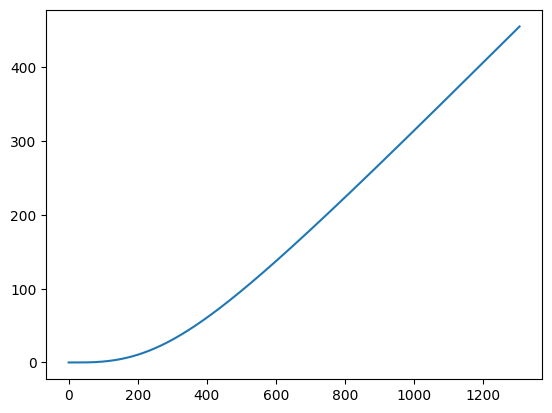

In [11]:
rhoeos=torch.logspace(-14, 0, 70000, device=device)
# rhoeos=torch.linspace(0, 0.1, 100, device=device)
epseos=netwdf.EnergyDensity(rhoeos*1.97**3, rhoeos*0., step=0.1).cpu().detach().numpy()*100/1.97**3 #Mev fm-3
rhoeos=rhoeos.detach().cpu().numpy()
p=rhoeos*np.gradient(epseos, rhoeos)  -epseos
# p2=(rhoeos[1:]+rhoeos[:-1])/2*np.diff(epseos) /np.diff(rhoeos) -(epseos[1:]+epseos[:-1])/2
# p3=rhoeos[1:]*np.diff(epseos) /np.diff(rhoeos) -epseos[1:]
plt.plot(epseos, p, label='(12, 0)')

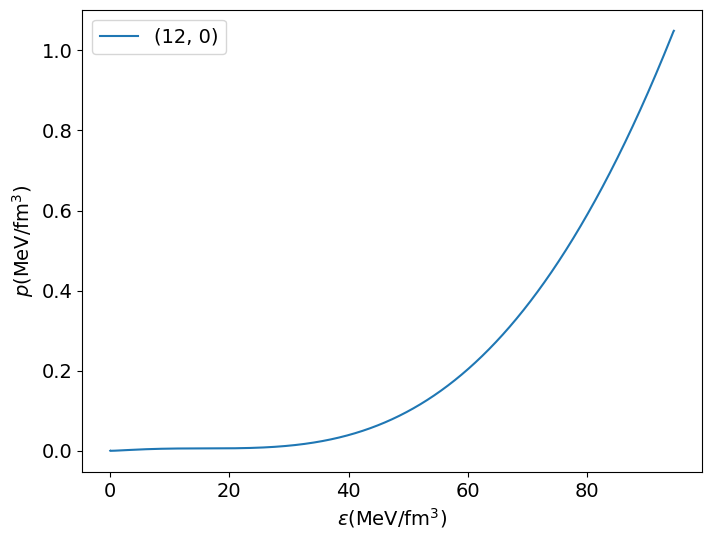

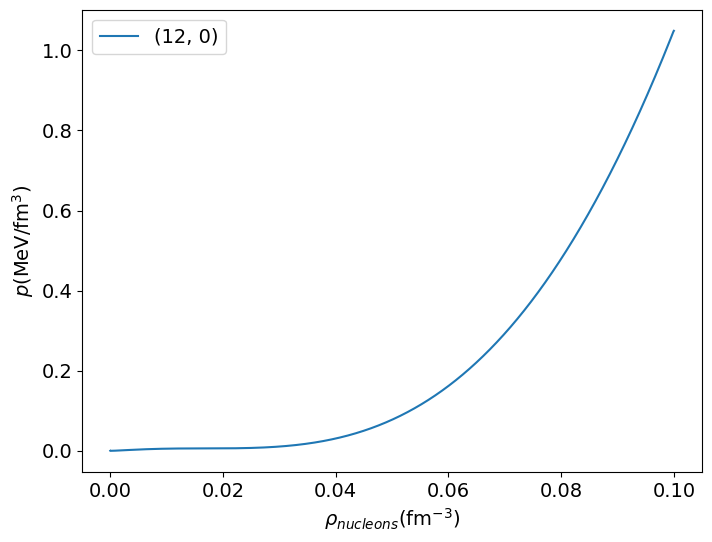

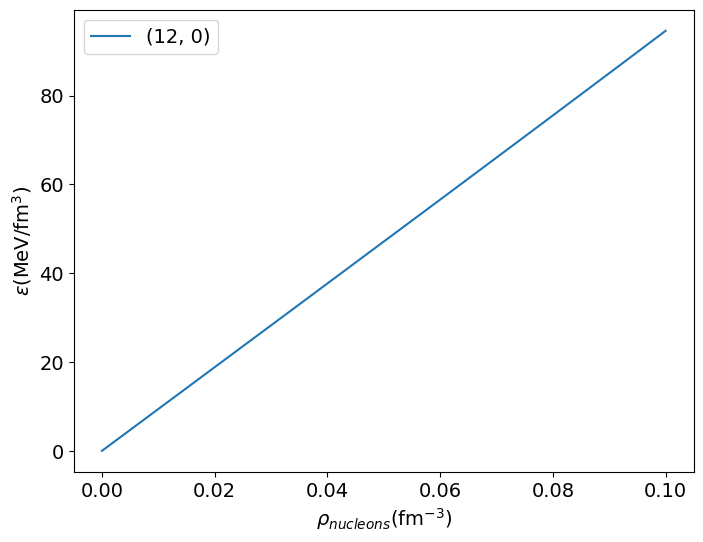

In [10]:
plt.rcParams['font.size'] = 14
plt.figure(figsize=(8, 6))
plt.plot(epseos, p, label='(12, 0)')
plt.xlabel(r'$\epsilon(\text{MeV/fm}^3)$')
plt.ylabel(r'$p(\text{MeV/fm}^3)$')
plt.legend()
plt.savefig("../eosdata/eosfigure/e-p_12,0.png", dpi=500, bbox_inches = 'tight')
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(rhoeos, p, label='(12, 0)')
plt.legend()
plt.xlabel(r'$\rho_{nucleons}(\text{fm}^{-3})$')
plt.ylabel(r'$p(\text{MeV/fm}^3)$')
plt.savefig("../eosdata/eosfigure/rho-p_12,0.png", dpi=500, bbox_inches = 'tight')

plt.figure(figsize=(8, 6))
plt.plot(rhoeos, epseos, label='(12, 0)')
plt.legend()
plt.xlabel(r'$\rho_{nucleons}(\text{fm}^{-3})$')
plt.ylabel(r'$\epsilon(\text{MeV/fm}^3)$')
plt.savefig("../eosdata/eosfigure/rho-e_12,0.png", dpi=500, bbox_inches = 'tight')

In [12]:
np.savetxt("../eosdata/eos_rmf_14.dat",np.array([rhoeos, p, epseos]).transpose())
# np.savetxt("../eosdata/eos_rmf-.dat",np.array([rhoeos[1:], p[1:], epseos[1:]]).transpose())

E''<0:  17167
[1.00000000e-13 1.00128371e-13 1.00214043e-13 ... 7.52881820e-07
 7.55461864e-07 7.76091118e-07]


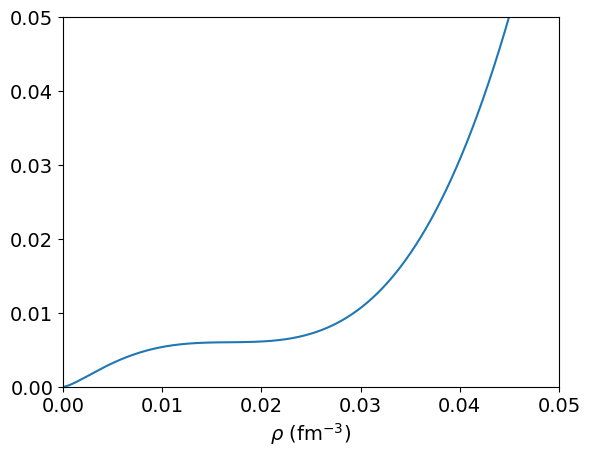

In [15]:
ee=np.gradient(p, rhoeos)
print("E''<0: ", np.count_nonzero(ee[:]<0))
print(rhoeos[np.where(ee[:]<0)])
plt.xlabel("$\\rho\ (\mathrm{fm^{-3}})$")
# plt.ylabel("$\epsilon\ (Mev/fm^{-3})$")
# plt.plot(rhoeos, epseos/rhoeos)
plt.plot(rhoeos, p)
# plt.plot(rhoeos[1:], p2)
# plt.plot(rhoeos[1:], p3)
plt.xlim(left=0, right=5e-2)
plt.ylim(bottom=0, top=5e-2)
plt.show()

In [ ]:
sigma=netwdf.findsigma(rho_n,rho_p,omega)

In [ ]:
sigma.cpu().detach().numpy()*100

In [ ]:
plt.plot(totalrho.cpu().numpy()[1:],eps.cpu().detach().numpy())